In [2]:
# ==========================================================
# Assignment 6 - Wholesale Customer Segmentation
# Step 1: Import Required Libraries
# ==========================================================
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt

# Machine Learning
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering


# Feature Scaling
from sklearn.preprocessing import StandardScaler

# Evaluation Metrics
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score
)

Matplotlib is building the font cache; this may take a moment.


In [6]:
# ==========================================================
# Step 2: Load the Dataset
# ==========================================================

# Load the wholesale customer dataset
df = pd.read_csv("raw_wholesale_customers.csv")

# Display the first 5 rows
print("========== FIRST 5 ROWS ==========")
display(df.head())

========== FIRST 5 ROWS ==========


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [10]:
# ==========================================================
# Step 3: Inspect the Dataset Structure
# ==========================================================

# Display dataset dimensions
print("========== DATASET SHAPE ==========")
print(df.shape)

# Display dataset information
print("\n========== DATASET INFO ==========")
df.info()

========== DATASET SHAPE ==========
(440, 8)

========== DATASET INFO ==========
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB


In [13]:
# ==========================================================
# Step 4: Select Features for Clustering
# ==========================================================

# Select only spending-related features
features = [
    "Fresh",
    "Milk",
    "Grocery",
    "Frozen",
    "Detergents_Paper",
    "Delicassen"
]

X = df[features].copy()

print("========== CLUSTERING FEATURES ==========")
display(X.head())

print("\nShape of X:", X.shape)

========== CLUSTERING FEATURES ==========


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,12669,9656,7561,214,2674,1338
1,7057,9810,9568,1762,3293,1776
2,6353,8808,7684,2405,3516,7844
3,13265,1196,4221,6404,507,1788
4,22615,5410,7198,3915,1777,5185



Shape of X: (440, 6)


In [14]:
# ==========================================================
# Step 5: Apply IQR Capping
# ==========================================================

# Apply IQR capping to each spending feature
for column in features:

    # Calculate Q1, Q3, and IQR
    Q1 = X[column].quantile(0.25)
    Q3 = X[column].quantile(0.75)
    IQR = Q3 - Q1

    # Compute lower and upper bounds
    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)

    # Clip outliers instead of removing rows
    X[column] = X[column].clip(lower_bound, upper_bound)

print("========== IQR CAPPING COMPLETED ==========")
display(X.describe())

========== IQR CAPPING COMPLETED ==========


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.000000,440.000000,440.00000,440.000000,440.000000,440.000000
mean,11357.568182,5048.592045,7236.37500,2507.085795,2392.616477,1266.715341
std,10211.542235,4386.377073,6596.53308,2408.297738,2940.794090,1083.069792
min,3.000000,55.000000,3.00000,25.000000,3.000000,3.000000
25%,3127.750000,1533.000000,2153.00000,742.250000,256.750000,408.250000
50%,8504.000000,3627.000000,4755.50000,1526.000000,816.500000,965.500000
75%,16933.750000,7190.250000,10655.75000,3554.250000,3922.000000,1820.250000
max,37642.750000,15676.125000,23409.87500,7772.250000,9419.875000,3938.250000


In [15]:
# ==========================================================
# Step 6: Feature Scaling using StandardScaler
# ==========================================================

from sklearn.preprocessing import StandardScaler

# Create the scaler
scaler = StandardScaler()

# Scale the six spending features
X_scaled = scaler.fit_transform(X)

# Convert scaled data back into a DataFrame
X_scaled = pd.DataFrame(X_scaled, columns=features)

print("========== SCALED FEATURES ==========")
display(X_scaled.head())

print("\n========== SUMMARY ==========")
display(X_scaled.describe().round(2))

========== SCALED FEATURES ==========


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,0.128573,1.051586,0.049267,-0.953244,0.095792,0.065892
1,-0.421627,1.086735,0.353865,-0.309735,0.306519,0.470759
2,-0.490647,0.858040,0.067935,-0.042437,0.382435,2.469440
3,0.187004,-0.879308,-0.457635,1.619962,-0.641923,0.481851
4,1.103677,0.082487,-0.005824,0.585275,-0.209575,2.469440



========== SUMMARY ==========


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.00,440.00,440.00,440.00,440.00,440.00
mean,-0.00,-0.00,0.00,0.00,-0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00
min,-1.11,-1.14,-1.10,-1.03,-0.81,-1.17
25%,-0.81,-0.80,-0.77,-0.73,-0.73,-0.79
50%,-0.28,-0.32,-0.38,-0.41,-0.54,-0.28
75%,0.55,0.49,0.52,0.44,0.52,0.51
max,2.58,2.43,2.45,2.19,2.39,2.47


========== ELBOW METHOD (SSE) ==========
k = 1: SSE = 2640.00
k = 2: SSE = 1728.19
k = 3: SSE = 1363.45
k = 4: SSE = 1202.41
k = 5: SSE = 1070.15
k = 6: SSE = 964.76
k = 7: SSE = 921.14
k = 8: SSE = 776.63
k = 9: SSE = 726.88
k = 10: SSE = 707.41


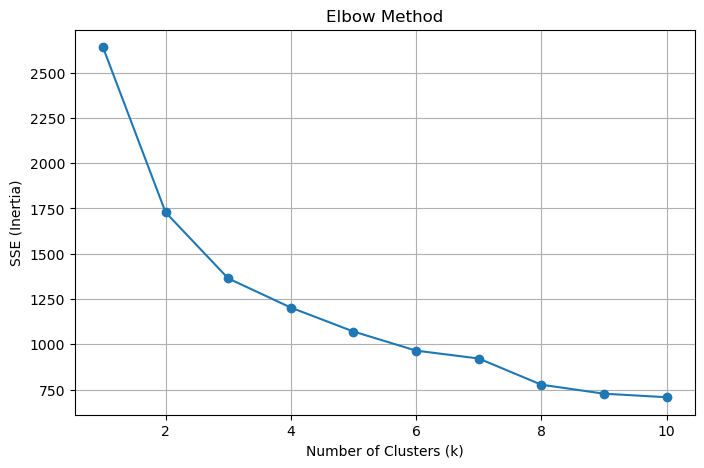

In [16]:
# ==========================================================
# Step 7: Elbow Method
# ==========================================================

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Store SSE (Inertia) values
sse = []

# Try different values of k
for k in range(1, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init="auto"
    )

    kmeans.fit(X_scaled)

    sse.append(kmeans.inertia_)

# Print SSE values
print("========== ELBOW METHOD (SSE) ==========")

for k, value in enumerate(sse, start=1):
    print(f"k = {k}: SSE = {value:.2f}")

# Plot Elbow Curve
plt.figure(figsize=(8,5))

plt.plot(range(1,11), sse, marker="o")

plt.title("Elbow Method")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("SSE (Inertia)")

plt.grid(True)

plt.show()

In [17]:
# ==========================================================
# Step 8: Train K-Means Clustering Model
# ==========================================================

from sklearn.cluster import KMeans

# Create K-Means model
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init="auto"
)

# Train the model
kmeans.fit(X_scaled)

# Add cluster labels to the original dataframe
df["Cluster"] = kmeans.labels_

print("========== K-MEANS COMPLETED ==========")

print("\nCluster Counts:")
print(df["Cluster"].value_counts().sort_index())

========== K-MEANS COMPLETED ==========

Cluster Counts:
Cluster
0     76
1    191
2     25
3     88
4     60
Name: count, dtype: int64


In [18]:
# ==========================================================
# Step 9: Evaluate K-Means Clustering
# ==========================================================

from sklearn.metrics import silhouette_score, davies_bouldin_score

# Calculate evaluation metrics
sil_score = silhouette_score(X_scaled, kmeans.labels_)
db_score = davies_bouldin_score(X_scaled, kmeans.labels_)

print("========== K-MEANS EVALUATION ==========")
print(f"Silhouette Score      : {sil_score:.3f}")
print(f"Davies-Bouldin Index  : {db_score:.3f}")

# Convert cluster centers back to original spending values
cluster_centers = scaler.inverse_transform(kmeans.cluster_centers_)

cluster_centers = pd.DataFrame(
    cluster_centers,
    columns=features
)

print("\n========== CLUSTER CENTERS (ORIGINAL VALUES) ==========")
display(cluster_centers.round(2))

========== K-MEANS EVALUATION ==========
Silhouette Score      : 0.283
Davies-Bouldin Index  : 1.270

========== CLUSTER CENTERS (ORIGINAL VALUES) ==========


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,9202.67,6833.30,9104.12,1326.16,3280.12,1871.76
1,8376.23,2150.65,3160.63,1646.33,779.25,674.02
2,17461.54,13805.60,17524.12,4120.57,5460.56,3583.64
3,22346.70,3409.14,3969.33,5819.60,583.07,1566.95
4,4916.98,10768.85,18350.13,1212.37,7780.02,981.37


In [19]:
# ==========================================================
# Step 10: Train Agglomerative Clustering
# ==========================================================

from sklearn.cluster import AgglomerativeClustering

# Create the model
agg_model = AgglomerativeClustering(
    n_clusters=5
)

# Train the model
agg_labels = agg_model.fit_predict(X_scaled)

# Save cluster labels
df["Agglomerative_Cluster"] = agg_labels

print("========== AGGLOMERATIVE CLUSTERING ==========")
print(df["Agglomerative_Cluster"].value_counts().sort_index())

========== AGGLOMERATIVE CLUSTERING ==========
Agglomerative_Cluster
0     70
1     72
2    164
3     55
4     79
Name: count, dtype: int64


In [20]:
# ==========================================================
# Step 11: Compare K-Means and Agglomerative
# ==========================================================

from sklearn.metrics import silhouette_score

kmeans_score = silhouette_score(X_scaled, kmeans.labels_)
agg_score = silhouette_score(X_scaled, agg_labels)

print("========== SILHOUETTE SCORE COMPARISON ==========")
print(f"K-Means              : {kmeans_score:.3f}")
print(f"Agglomerative        : {agg_score:.3f}")

if kmeans_score > agg_score:
    print("\nK-Means produced better-separated clusters.")
else:
    print("\nAgglomerative produced better-separated clusters.")

========== SILHOUETTE SCORE COMPARISON ==========
K-Means              : 0.283
Agglomerative        : 0.218

K-Means produced better-separated clusters.


In [21]:
# ==========================================================
# Step 12: Sanity Check
# ==========================================================

sample_clients = [0, 100, 200]

results = df.loc[
    sample_clients,
    [
        "Channel",
        "Region",
        "Fresh",
        "Milk",
        "Grocery",
        "Frozen",
        "Detergents_Paper",
        "Delicassen",
        "Cluster",
        "Agglomerative_Cluster"
    ]
]

print("========== SANITY CHECK ==========")
display(results)

========== SANITY CHECK ==========


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Cluster,Agglomerative_Cluster
0,2,3,12669,9656,7561,214,2674,1338,0,4
100,2,3,11594,7779,12144,3252,8035,3029,2,1
200,2,1,3067,13240,23127,3941,9959,731,4,1


In [ ]:
# ==========================================================
# Step 13: Save Final Dataset
# ==========================================================

df.to_csv(
    "segmented_wholesale_customers.csv",
    index=False
)

print("Dataset saved successfully!")